# 🏢 Анализ рынка недвижимости Астаны
Бизнес-задача: Провести разведочный анализ данных (EDA), очистить базу от аномалий (фейковые цены, неполные адреса) и подтвердить гипотезы о ценообразовании статистическими тестами.

Стек: Python, Pandas, Seaborn, SciPy, SQLite.


In [20]:
import piplite
await piplite.install('seaborn')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sqlite3

# Загрузка сырых данных
file_path = "data/ast.csv" 
df = pd.read_csv(file_path)
print(f"Исходный размер данных: {df.shape[0]} строк")

Исходный размер данных: 5003 строк


### 1. Предобработка и очистка данных (ETL)
В сырых данных присутствуют экстремальные выбросы (вплоть до 33 млрд тенге) и системные ошибки заполнения.

Шаги очистки:

1.  Расчет базовой метрики: price_per_m2.

2.  Удаление полных дубликатов.

3.  Математическая фильтрация ценовых выбросов с использованием межквартильного размаха (IQR).

4.  Очистка неявных пропусков и текстовых артефактов в локациях.

In [2]:
# Базовая метрика
df['price_per_m2'] = df['price'] / df['area_m2']
df = df.drop_duplicates()

# Метод Тьюки (IQR) для поиска нормальных границ цены
Q1 = df['price_per_m2'].quantile(0.25)
Q3 = df['price_per_m2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Применение фильтра
filtered_df = df[(df['price_per_m2'] >= lower_bound) & (df['price_per_m2'] <= upper_bound)].copy()

# Текстовая нормализация
filtered_df = filtered_df[filtered_df['district'] != 'Астана, Казахстан']
filtered_df['apartment_condition'] = filtered_df['apartment_condition'].replace({'Не указано': 'Неизвестно'})
filtered_df['district'] = filtered_df['district'].str.replace(', Астана, Казахстан', '')

print(f"Нижняя граница нормы: {lower_bound:,.0f} тг/кв.м")
print(f"Верхняя граница нормы: {upper_bound:,.0f} тг/кв.м")
print(f"Строк после очистки: {filtered_df.shape[0]}")

Нижняя граница нормы: 128,321 тг/кв.м
Верхняя граница нормы: 1,151,211 тг/кв.м
Строк после очистки: 3966


## 2. Базовый разведочный анализ (Basic EDA)
Прежде чем искать сложные закономерности, посмотрим на общую структуру очищенных данных: распределение по районам и базовую статистику (средние цены, площади).

📊 Базовая статистика рынка Астаны:


,price,area_m2,price_per_m2,rooms
count,3966.0,3966.0,3966.0,3966.0
mean,45516106.4,69.6,646077.7,2.3
std,29632410.6,35.4,174478.7,1.0
min,5000000.0,14.0,207792.2,1.0
25%,27000000.0,43.0,511340.1,2.0
50%,37300000.0,62.0,631074.3,2.0
75%,54500000.0,85.7,757575.8,3.0
max,375000000.0,503.0,1150769.2,10.0


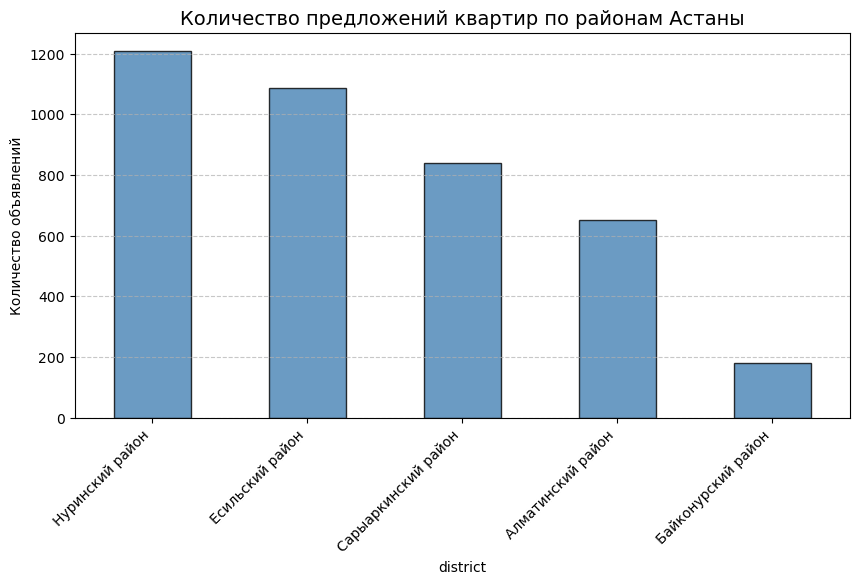

Самый популярный район для продажи: Нуринский район (1208 объявлений)


In [3]:
# 1. Выводим сводную статистику по числовым колонкам (округляем для красоты)
print("📊 Базовая статистика рынка Астаны:")
display(filtered_df[['price', 'area_m2', 'price_per_m2', 'rooms']].describe().round(1))

# 2. Смотрим, сколько квартир продают в каждом районе
plt.figure(figsize=(10, 5))
district_counts = filtered_df['district'].value_counts()

# Строим простой и понятный столбчатый график 
district_counts.plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Количество предложений квартир по районам Астаны', fontsize=14)
plt.ylabel('Количество объявлений')
plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Самый популярный район для продажи: {district_counts.index[0]} ({district_counts.iloc[0]} объявлений)")

### 2. Разведочный анализ (EDA) и корреляции
Оценка мультиколлинеарности: поиск факторов, имеющих наибольший вес в формировании цены квадратного метра.

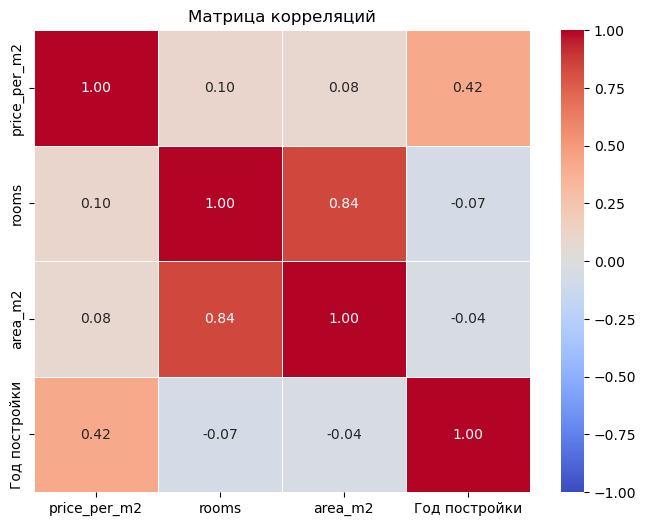

In [4]:
plt.figure(figsize=(8, 6))

cols_to_compare = ['price_per_m2', 'rooms', 'area_m2', 'Год постройки']
corr = filtered_df[cols_to_compare].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Матрица корреляций')
plt.show()

### 3. Статистическая проверка гипотез (ANOVA)
Гипотеза: Количество комнат влияет на стоимость квадратного метра.
Метод: Дисперсионный анализ (A/B тестирование разницы средних) между 1-комнатными и 4-комнатными лотами.

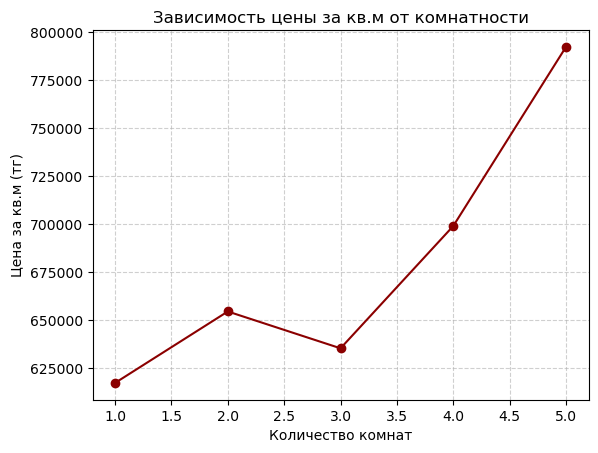

P-value: 1.00519e-14
Разница статистически значима.


In [5]:
# Фильтрация жилого фонда
rooms_df = filtered_df[(filtered_df['rooms'] > 0) & (filtered_df['rooms'] < 6)]

# Визуализация тренда
grouped_rooms = rooms_df.groupby('rooms')['price_per_m2'].mean().round()
grouped_rooms.plot(kind='line', marker='o', color='darkred')
plt.title('Зависимость цены за кв.м от комнатности')
plt.xlabel('Количество комнат')
plt.ylabel('Цена за кв.м (тг)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Расчет p-value
price_1_room = rooms_df[rooms_df['rooms'] == 1]['price_per_m2']
price_4_room = rooms_df[rooms_df['rooms'] == 4]['price_per_m2']

f_stat, p_value = stats.f_oneway(price_1_room, price_4_room)

print(f"P-value: {p_value:.5e}")
if p_value < 0.05:
    print("Разница статистически значима.")
else:
    print("Статистически значимой разницы нет.")



---
### Влияние года постройки на стоимость
Проверим исторический тренд застройки города и найдем ценовые аномалии в свежих ЖК.

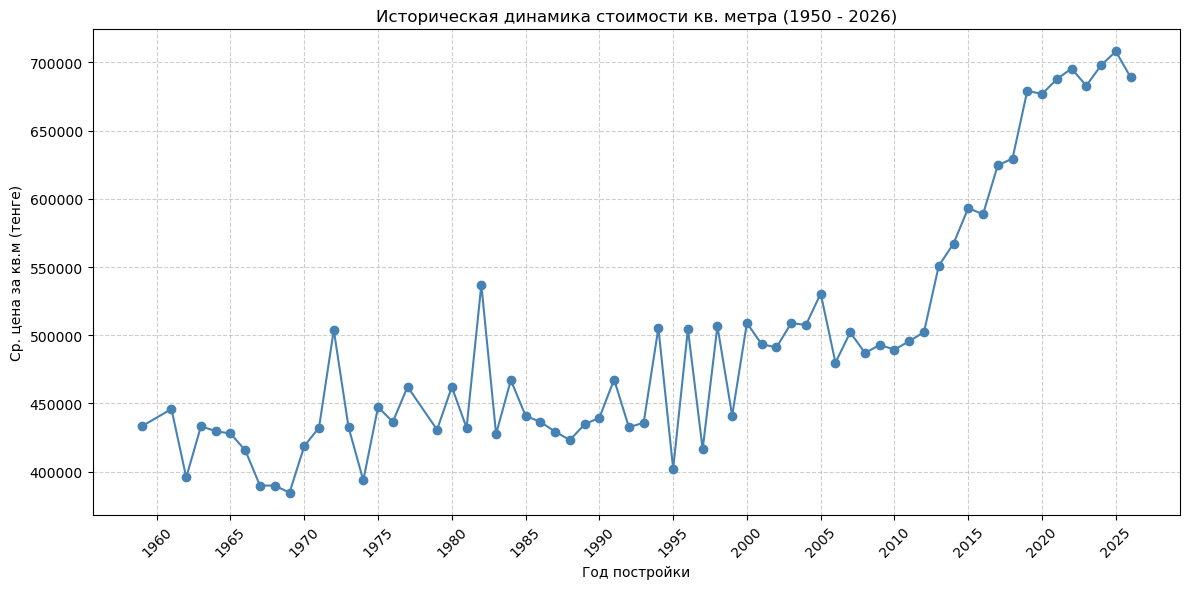

In [6]:
# Отсекаем опечатки в годах (оставляем период с 1950 по 2026)
years_df = filtered_df[(filtered_df['Год постройки'] >= 1950) & (filtered_df['Год постройки'] <= 2026)]

# Группируем по годам
grouped_year = years_df.groupby('Год постройки')['price_per_m2'].mean().round()

grouped_year.plot(kind='line', marker='o', figsize=(12, 6), color='steelblue')
plt.title('Историческая динамика стоимости кв. метра (1950 - 2026)')
plt.xlabel('Год постройки')
plt.ylabel('Ср. цена за кв.м (тенге)')
plt.xticks(range(1960, 2030, 5), rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Влияние состояния ремонта на стоимость

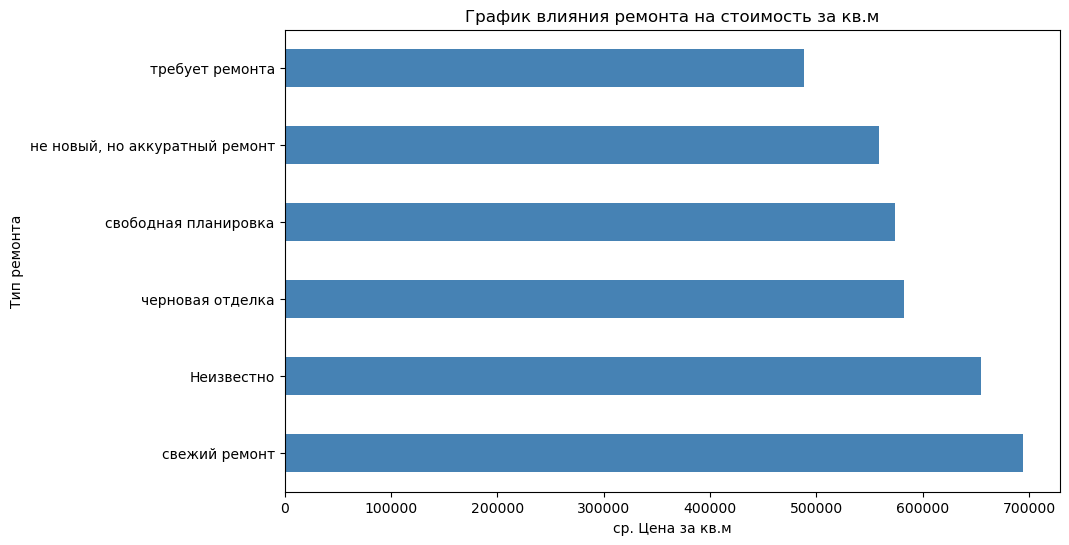

In [7]:
grouped_remont = filtered_df.groupby('apartment_condition')['price_per_m2'].mean().sort_values(ascending=False).round()
grouped_remont.plot(kind = 'barh', figsize = (10,6), color = 'steelblue')
plt.title('График влияния ремонта на стоимость за кв.м')
plt.xlabel('ср. Цена за кв.м')
plt.ylabel('Тип ремонта')
plt.show()

### 🗄️ Интеграция с SQL (ETL-процесс)
Для демонстрации навыков Data Engineering, очищенный датасет загружен в локальную базу данных SQLite. Ниже представлен SQL-запрос, который формирует итоговую витрину данных по районам, используя агрегатные функции.

In [8]:
import sqlite3

# Подключаемся к базе прямо в оперативной памяти (RAM)
conn = sqlite3.connect(':memory:')

# Перекидываем наш чистый DataFrame (filtered_df) в SQL-таблицу 'apartments'
filtered_df.to_sql('apartments', conn, if_exists='replace', index=False)
print("Данные успешно залиты в оперативную SQL-базу!\n")


Данные успешно залиты в оперативную SQL-базу!



### 🚀 Продвинутая аналитика: Поиск "Элиты" рынка (Топ-3 по районам)
Для выделения наиболее дорогих предложений на рынке использованы **оконные функции SQL (`ROW_NUMBER() OVER`)**. 

**Технические детали:**
* Использован `PARTITION BY district` для разделения данных на логические группы (районы).
* Применена сортировка `ORDER BY price_per_m2 DESC` внутри каждого "окна".
* Наложен фильтр `WHERE price_per_m2 > 200000` для исключения ценовых аномалий и ошибок ввода.


In [18]:
# 1. Поднимаем SQLite базу прямо в оперативной памяти
conn = sqlite3.connect(':memory:')

# 2. Загружаем туда нашу ИДЕАЛЬНО чистую таблицу
filtered_df.to_sql('apartments', conn, index=False, if_exists='replace')

# 3. Хардкорный SQL запрос
advanced_sql = """
WITH RankedApartments AS (
    SELECT 
        district AS "Район",
        rooms AS "Комнаты",
        price AS "Цена",
        price_per_m2 AS "Цена_за_кв_м",
        ROW_NUMBER() OVER (PARTITION BY district ORDER BY price_per_m2 DESC) AS rank_in_district
    FROM apartments
    WHERE price_per_m2 > 200000 -- Добавили тот самый фильтр из твоего описания!
)
SELECT 
    "Район", 
    "Комнаты", 
    "Цена", 
    "Цена_за_кв_м", 
    rank_in_district AS "Место_по_району"
FROM RankedApartments
WHERE rank_in_district <= 3;
"""

# 4. Выполняем и выводим витрину данных
top_apartments = pd.read_sql(advanced_sql, conn)
print("🏆 Витрина данных: ТОП-3 самых дорогих лота по каждому району")
print(top_apartments)

🏆 Витрина данных: ТОП-3 самых дорогих лота по каждому району
                  Район  Комнаты       Цена  Цена_за_кв_м  Место_по_району
0     Алматинский район      3.0  135000000  1.080000e+06                1
1     Алматинский район      3.0   73999999  1.057143e+06                2
2     Алматинский район      7.0  375000000  1.056338e+06                3
3    Байконурский район      3.0   92000000  1.022222e+06                1
4    Байконурский район      3.0  110000000  1.018519e+06                2
5    Байконурский район      5.0  170000000  8.212560e+05                3
6       Есильский район      3.0   74800000  1.150769e+06                1
7       Есильский район      4.0  138000000  1.150000e+06                2
8       Есильский район      3.0   74500000  1.146154e+06                3
9       Нуринский район      3.0   90644610  1.149000e+06                1
10      Нуринский район      2.0   55900000  1.140816e+06                2
11      Нуринский район      3.0  11400

### 📌 Вывод по топ-3 лотам
Есильский район ожидаемо занял лидирующую позицию по цене за кв.м  
это административный центр Астаны на левом берегу, где сосредоточены 
правительственные здания, бизнес-центры и премиальные ЖК. 
Разрыв с периферийными районами подтверждает, что локация  
главный ценообразующий фактор на рынке недвижимости Астаны.

### 🏗️ Продвинутая аналитика: Сегментация рынка по эпохам застройки
Для понимания исторической эволюции рынка недвижимости Астаны, сырые данные по годам были сгруппированы в три крупные категории (эпохи) с использованием **условной логики SQL (`CASE WHEN`)**. 

**Технические детали:**
* Использована конструкция `CASE WHEN ... THEN ... ELSE` для динамического создания кастомных текстовых когорт на уровне базы данных, без создания дополнительных таблиц.
* Применены агрегатные функции `COUNT()` и `AVG()` для расчета объемов рынка и средних показателей внутри каждой когорты.
* Исключены "грязные" данные через фильтр `WHERE "Год постройки" IS NOT NULL`.

In [17]:
new_sql = """
select
    case
        when "Год постройки" < 2000 then 'Старый фонд (до 2000г.)'
        when "Год постройки" between 2000 and 2015 then 'Современное жилье (2000-2015г.)'
        else 'Новостройки (после 2015г.)'
    end as building_epoch,
    count(*) as [Количество квартир],
    round(avg(area_m2),1) as [Средняя площадь кв.],
    round(avg(price_per_m2),0) as [Средняя цена за кв.м]
    from apartments
    where "Год постройки" is not null
    group by 
    case
        when "Год постройки" < 2000 then 'Старый фонд (до 2000г.)'
        when "Год постройки" between 2000 and 2015 then 'Современное жилье (2000-2015г.)'
        else 'Новостройки (после 2015г.)'
    end
    order by round(avg(price_per_m2),0) desc
"""

aparr = pd.read_sql(new_sql, conn)
print("Сегментация квартир по году постройки")
print(aparr)

Сегментация квартир по году постройки
                    building_epoch  Количество квартир  Средняя площадь кв.  \
0       Новостройки (после 2015г.)                3069                 66.5   
1  Современное жилье (2000-2015г.)                 741                 85.5   
2          Старый фонд (до 2000г.)                 156                 55.3   

   Средняя цена за кв.м  
0              687045.0  
1              519095.0  
2              443297.0  


### 📌 Вывод по эпохам застройки
Новостройки (после 2015г.) дороже старого фонда примерно в 1.5 раза. 
Это согласуется с корреляционным анализом, heatmap показала 
коэффициент 0.42 между годом постройки и ценой за кв.м, 
что говорит об умеренно сильной положительной связи. 
Покупатели платят премию за современные планировки, 
новые коммуникации и инфраструктуру новых ЖК.